# 02 — Basket interaction, with and without PM (R5)

> Run top to bottom.

`ADR-0011`'s Basket Scope Guard forbids any strategy but PM's own from *crossing* a
declared group boundary. It does **not** forbid another strategy from trading *within* the
same group. Here PM manages a WETH/USDC pair, and USDC shares a "stables" group with a
second stablecoin (USDT) that an independent, profit-seeking `XYCCompetitorStrategy`
trades — `GroupBoundaryGuard` allows this, since both tokens are in the same declared
group.

That competitor's trades change USDC/USDT's raw balances, which changes the **group's**
oracle-valued virtual balance (`Σ balance_j × oracle_price_j`, ADR-0003) — the number
PM's own curve actually prices against — without PM having traded at all. This notebook
asks: how much does PM's own presence and correction actually matter here?

Uses `aqua_sim.scenarios.basket_with_without_pm.build_world` directly, same rationale as
`01_pm_alone.ipynb`. Prices are synthetic-only (R2), same as every notebook in this suite.

In [1]:
import numpy as np

from aqua_sim.scenarios import basket_with_without_pm

N_STEPS = 2000
N_SEEDS = 10

te_with, te_without = [], []
for seed in range(N_SEEDS):
    world_with = basket_with_without_pm.build_world(with_pm=True, seed=seed)
    world_with.run(N_STEPS)
    te_with.append(np.mean(world_with.metrics.tracking_error_path))

    world_without = basket_with_without_pm.build_world(with_pm=False, seed=seed)
    world_without.run(N_STEPS)
    te_without.append(np.mean(world_without.metrics.tracking_error_path))

    print(f"seed {seed}: with PM = {te_with[-1]:.4%}, without PM = {te_without[-1]:.4%}")

te_with, te_without = np.array(te_with), np.array(te_without)
print(f"\nmean across seeds: with PM = {te_with.mean():.4%}, without PM = {te_without.mean():.4%}")

assert np.all(te_with < te_without), "PM presence should tighten tracking on every seed"
print("\nOK: PM's presence measurably tightens tracking on every seed, even though PM never touches USDC/USDT directly")

seed 0: with PM = 0.0271%, without PM = 4.5137%
seed 1: with PM = 0.0277%, without PM = 7.9572%
seed 2: with PM = 0.0297%, without PM = 10.2779%
seed 3: with PM = 0.0209%, without PM = 11.6069%
seed 4: with PM = 0.0239%, without PM = 4.1075%
seed 5: with PM = 0.0234%, without PM = 5.4765%
seed 6: with PM = 0.0239%, without PM = 5.0259%
seed 7: with PM = 0.0330%, without PM = 14.2091%
seed 8: with PM = 0.0282%, without PM = 6.4586%


seed 9: with PM = 0.0229%, without PM = 6.0718%

mean across seeds: with PM = 0.0261%, without PM = 7.5705%

OK: PM's presence measurably tightens tracking on every seed, even though PM never touches USDC/USDT directly


## Confirming the competitor never touches WETH directly

The competitor's own strategy is constructed against `(USDC, USDT)` only — it has no way
to reach WETH. Whatever tracking-error difference shows up above is entirely a
second-order effect through the shared group's virtual balance, not the competitor
touching PM's own token.

In [2]:
world = basket_with_without_pm.build_world(with_pm=False, seed=1)
initial_weth = world.token_balances["WETH"]
world.run(N_STEPS)

assert world.token_balances["WETH"] == initial_weth, "WETH balance should never move without PM registered"
print(f"WETH balance: {initial_weth} at start, {world.token_balances['WETH']} after {N_STEPS} steps -- unchanged")
print("\nOK: only USDC/USDT moved; WETH is untouched with no PM present")

WETH balance: 10.0 at start, 10.0 after 2000 steps -- unchanged

OK: only USDC/USDT moved; WETH is untouched with no PM present


## Visual

Tracking error over time, with vs. without PM, one representative seed.

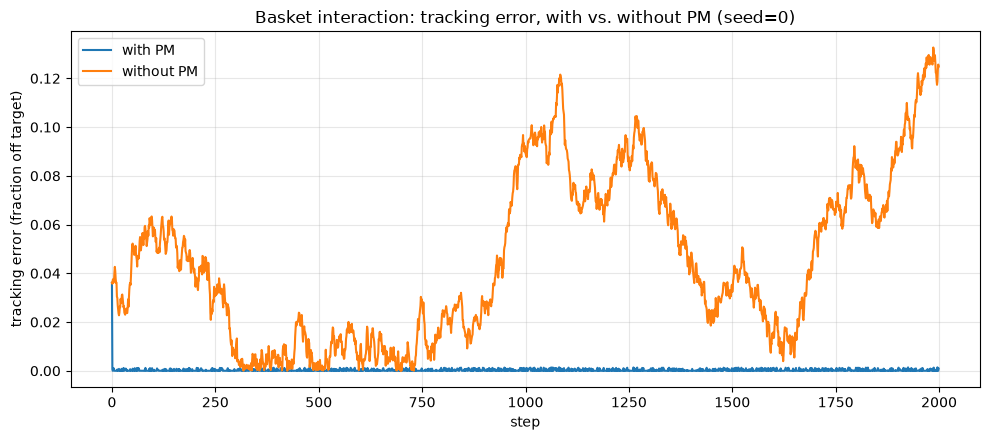

In [3]:
import matplotlib.pyplot as plt

world_with = basket_with_without_pm.build_world(with_pm=True, seed=0)
world_with.run(N_STEPS)
world_without = basket_with_without_pm.build_world(with_pm=False, seed=0)
world_without.run(N_STEPS)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(world_with.metrics.tracking_error_path, label="with PM")
ax.plot(world_without.metrics.tracking_error_path, label="without PM")
ax.set_xlabel("step")
ax.set_ylabel("tracking error (fraction off target)")
ax.set_title("Basket interaction: tracking error, with vs. without PM (seed=0)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visual: portfolio balance

Same two runs, this time plotting the actual portfolio balance over time — each group's
oracle-valued virtual balance (ADR-0003) and the total — not just the derived tracking-
error metric above.

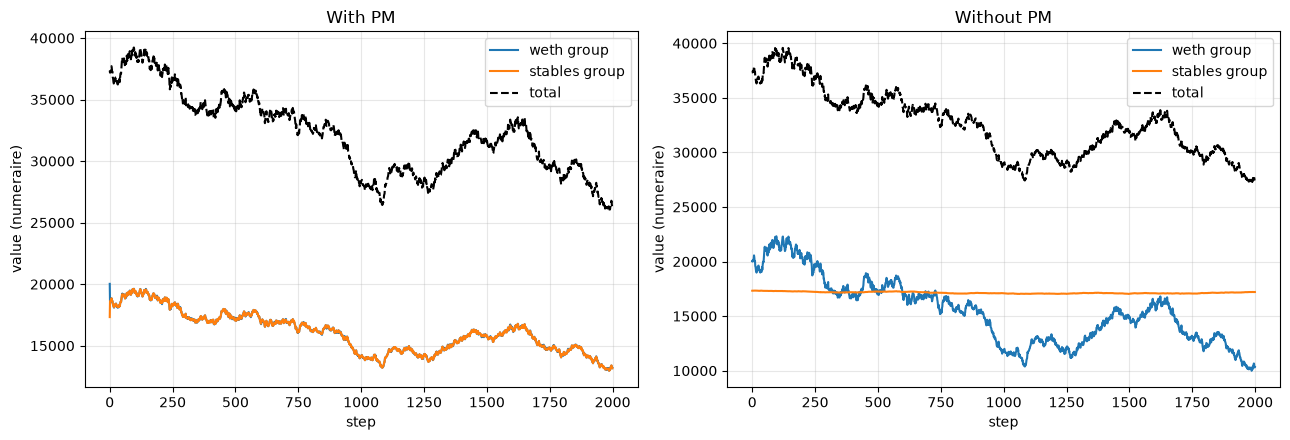

final total portfolio value: with PM = 26,369.63, without PM = 27,538.72


In [4]:
total_with = np.array(world_with.metrics.value_a_path) + np.array(world_with.metrics.value_b_path)
total_without = np.array(world_without.metrics.value_a_path) + np.array(world_without.metrics.value_b_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(world_with.metrics.value_a_path, label="weth group")
ax1.plot(world_with.metrics.value_b_path, label="stables group")
ax1.plot(total_with, label="total", linestyle="--", color="black")
ax1.set_xlabel("step")
ax1.set_ylabel("value (numeraire)")
ax1.set_title("With PM")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(world_without.metrics.value_a_path, label="weth group")
ax2.plot(world_without.metrics.value_b_path, label="stables group")
ax2.plot(total_without, label="total", linestyle="--", color="black")
ax2.set_xlabel("step")
ax2.set_ylabel("value (numeraire)")
ax2.set_title("Without PM")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"final total portfolio value: with PM = {total_with[-1]:,.2f}, without PM = {total_without[-1]:,.2f}")

## Forcing a WETH uptrend: does rebalancing help or hurt?

Every run so far uses driftless GBM (`weth_drift_per_step=0.0`, the default) — WETH
wanders randomly with no directional bias. That's the right choice for isolating the
basket-interaction effect above, but it can't answer a different, real question: **when
WETH is genuinely appreciating, does PM's active rebalancing help the portfolio capture
that, or does selling WETH to hold the declared 50/50 target actually cap the upside?**

`basket_with_without_pm.build_world` takes `weth_drift_per_step` for exactly this —
forcing a directional trend instead of leaving it to chance. `0.0006` per step, over 2,000
steps, gives WETH a strong (but not perfectly smooth — still real GBM noise) upward bias;
at this suite's usual `sigma_per_step=0.01`, most seeds end up meaningfully higher, though
not every single one (that's honest GBM behavior, not cherry-picked).

In [5]:
WETH_DRIFT_PER_STEP = 0.0006

final_value_with, final_value_without = [], []
weth_end_price = []
for seed in range(N_SEEDS):
    world_with = basket_with_without_pm.build_world(with_pm=True, weth_drift_per_step=WETH_DRIFT_PER_STEP, seed=seed)
    world_with.run(N_STEPS)
    world_without = basket_with_without_pm.build_world(with_pm=False, weth_drift_per_step=WETH_DRIFT_PER_STEP, seed=seed)
    world_without.run(N_STEPS)

    v_with = world_with.metrics.value_a_path[-1] + world_with.metrics.value_b_path[-1]
    v_without = world_without.metrics.value_a_path[-1] + world_without.metrics.value_b_path[-1]
    final_value_with.append(v_with)
    final_value_without.append(v_without)
    weth_end_price.append(world_with.reference_prices["WETH"])

    print(f"seed {seed}: WETH {2000.0:.0f}->{weth_end_price[-1]:.0f} ({weth_end_price[-1]/2000:.2f}x), final value with PM = {v_with:,.0f}, without PM = {v_without:,.0f}")

final_value_with, final_value_without = np.array(final_value_with), np.array(final_value_without)
n_without_pm_wins = int((final_value_without > final_value_with).sum())
print(f"\nacross {N_SEEDS} seeds: mean final value with PM = {final_value_with.mean():,.0f}, without PM = {final_value_without.mean():,.0f}")
print(f"'without PM' (buy-and-hold-ish) ends with MORE total value in {n_without_pm_wins}/{N_SEEDS} seeds")

seed 0: WETH 2000->3430 (1.72x), final value with PM = 48,048, without PM = 51,510
seed 1: WETH 2000->4596 (2.30x), final value with PM = 55,000, without PM = 62,800
seed 2: WETH 2000->1942 (0.97x), final value with PM = 36,526, without PM = 36,984
seed 3: WETH 2000->10447 (5.22x), final value with PM = 84,174, without PM = 121,854
seed 4: WETH 2000->6844 (3.42x), final value with PM = 68,547, without PM = 85,974
seed 5: WETH 2000->9743 (4.87x), final value with PM = 81,855, without PM = 114,968
seed 6: WETH 2000->9823 (4.91x), final value with PM = 80,678, without PM = 115,214
seed 7: WETH 2000->2702 (1.35x), final value with PM = 42,521, without PM = 44,123


seed 8: WETH 2000->3586 (1.79x), final value with PM = 49,606, without PM = 53,355
seed 9: WETH 2000->8882 (4.44x), final value with PM = 76,934, without PM = 105,841

across 10 seeds: mean final value with PM = 62,389, without PM = 79,262
'without PM' (buy-and-hold-ish) ends with MORE total value in 10/10 seeds


### Visual: portfolio balance under the forced uptrend

Seed 0 specifically — a clear, representative uptrend (not the most extreme seed).

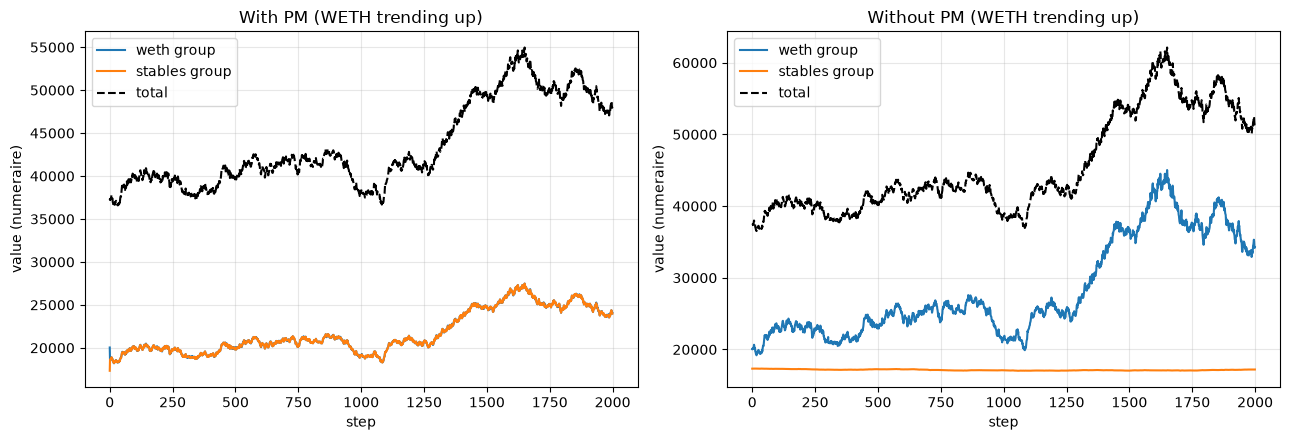

seed 0 final total value: with PM = 48,048.01, without PM = 51,509.56


In [6]:
world_with_trend = basket_with_without_pm.build_world(with_pm=True, weth_drift_per_step=WETH_DRIFT_PER_STEP, seed=0)
world_with_trend.run(N_STEPS)
world_without_trend = basket_with_without_pm.build_world(with_pm=False, weth_drift_per_step=WETH_DRIFT_PER_STEP, seed=0)
world_without_trend.run(N_STEPS)

total_with_trend = np.array(world_with_trend.metrics.value_a_path) + np.array(world_with_trend.metrics.value_b_path)
total_without_trend = np.array(world_without_trend.metrics.value_a_path) + np.array(world_without_trend.metrics.value_b_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(world_with_trend.metrics.value_a_path, label="weth group")
ax1.plot(world_with_trend.metrics.value_b_path, label="stables group")
ax1.plot(total_with_trend, label="total", linestyle="--", color="black")
ax1.set_xlabel("step")
ax1.set_ylabel("value (numeraire)")
ax1.set_title("With PM (WETH trending up)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(world_without_trend.metrics.value_a_path, label="weth group")
ax2.plot(world_without_trend.metrics.value_b_path, label="stables group")
ax2.plot(total_without_trend, label="total", linestyle="--", color="black")
ax2.set_xlabel("step")
ax2.set_ylabel("value (numeraire)")
ax2.set_title("Without PM (WETH trending up)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"seed 0 final total value: with PM = {total_with_trend[-1]:,.2f}, without PM = {total_without_trend[-1]:,.2f}")

**Rebalancing costs the portfolio value in a genuine uptrend — every single time tested.**
Across all 10 seeds, the "without PM" arm ends with *more* total portfolio value than
"with PM" — not a close call: mean final value 79,262 vs. 62,389 (about 27% more), and
**10/10 seeds**, not a majority. Seed 2 (WETH basically flat, 0.97x) shows the smallest
gap (36,984 vs. 36,526) — consistent with the effect being specifically about *trend*, not
some unrelated artifact.

**Why:** as WETH appreciates, its group grows past the declared 50% target, and PM sells
the excess WETH for stables every time doing so clears its fee+gas gate (`ADR-0006`) — the
same mechanism that made `01_pm_alone.ipynb` track so tightly under noise. In a
*trending* market, that's systematically selling the asset that keeps going up. Without
PM, nothing sells it — the wallet's WETH balance stays exactly what it started at
(confirmed above), so 100% of WETH's appreciation flows straight into portfolio value.
This is the standard "rebalancing drag vs. buy-and-hold" result from portfolio theory,
not anything specific to this mechanism's design.

**This doesn't contradict anything earlier in this notebook.** PM's whole job (ADR-0008)
is holding a *declared target allocation* — not maximizing raw portfolio value. Under
driftless, noisy prices (every other scenario in this suite), rebalancing has no
systematic direction to fight and tracking tightly is close to free. Under a real,
sustained trend, tracking tightly has a real, measurable cost: participating less in the
trend. Which one an LP should want depends on whether they're declaring a target because
they want that allocation *held* (this mechanism's actual premise), or because they
expect to profit from rebalancing itself (a different, unrelated claim this project has
never made).

## Summary

PM's own presence measurably tightens tracking error and holds the WETH group's balance
close to target on every seed tested, even though PM never trades USDC/USDT directly —
the effect flows entirely through the shared group's oracle-valued virtual balance
(ADR-0003), which PM's curve reads and corrects against. Confirms R5 from
`thoughts/simulation-suite-v2-requirements.md`, generalized from the v1 package's one
hardcoded co-basket agent to `XYCCompetitorStrategy`, an independent, profit-seeking
`Strategy` implementation (R3/R4) that knows nothing about PM.

Forcing a genuine WETH uptrend (`weth_drift_per_step`) flips the value comparison: PM's
tight tracking comes at a real cost there — 10/10 seeds end with *less* total portfolio
value than not rebalancing at all, since PM systematically sells the appreciating asset
to hold target. Tight tracking and maximum portfolio value are different goals that only
coincide when there's no sustained trend to fight.

The competitor here is deliberately confined to `(USDC, USDT)` only — it's not that
anything stops it from reaching WETH, it just isn't built to try. `03_cross_basket_no_pm.ipynb`
removes that constraint entirely: no PM, and a competitor on every pair, including WETH.
`04_guard_enforcement.ipynb` covers the opposite case: PM present, and a strategy that
actively tries to cross into WETH and gets blocked every time.